<a href="https://colab.research.google.com/github/madhangowda20066-oss/NVIDIA-Internship/blob/main/Day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Version: 2.20.0
Dataset Location: /root/.keras/datasets/flower_photos/flower_photos
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


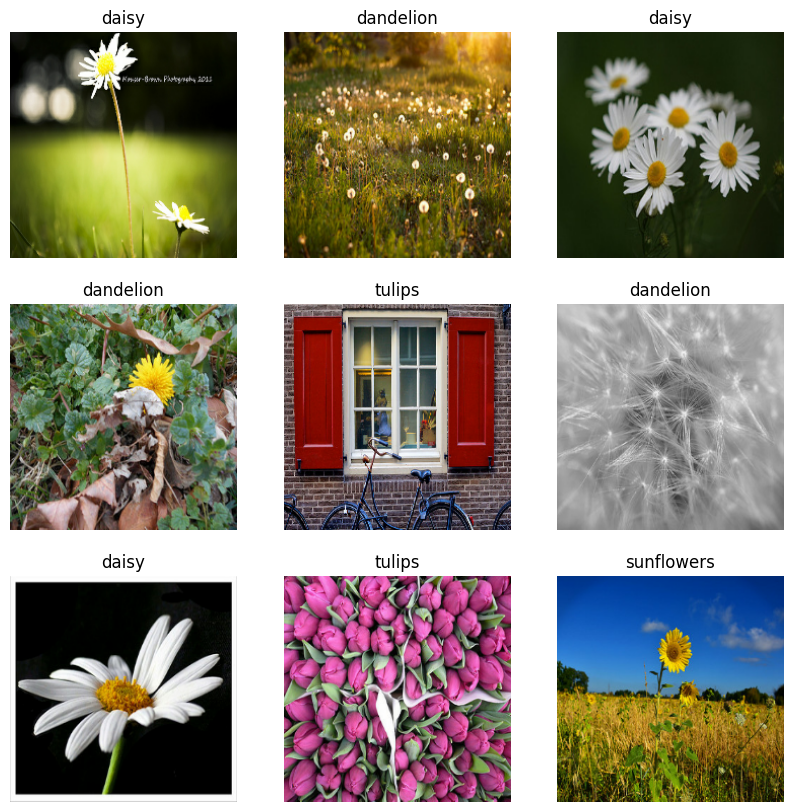

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.7384 - loss: 0.7014 - val_accuracy: 0.8447 - val_loss: 0.4424
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.8372 - loss: 0.4437 - val_accuracy: 0.8665 - val_loss: 0.3913
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8522 - loss: 0.3972 - val_accuracy: 0.8842 - val_loss: 0.3451
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8624 - loss: 0.3655 - val_accuracy: 0.8842 - val_loss: 0.3486
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.8733 - loss: 0.3443 - val_accuracy: 0.8801 - val_loss: 0.3518
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8774 - loss: 0.3334 - val_accuracy: 0.8883 - val_loss: 0.3237
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8890 - loss: 0.3111 - val_accuracy: 0.8978 - val_loss: 0.3327
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8937 - loss: 0.2917 - val_accuracy: 0.8651 

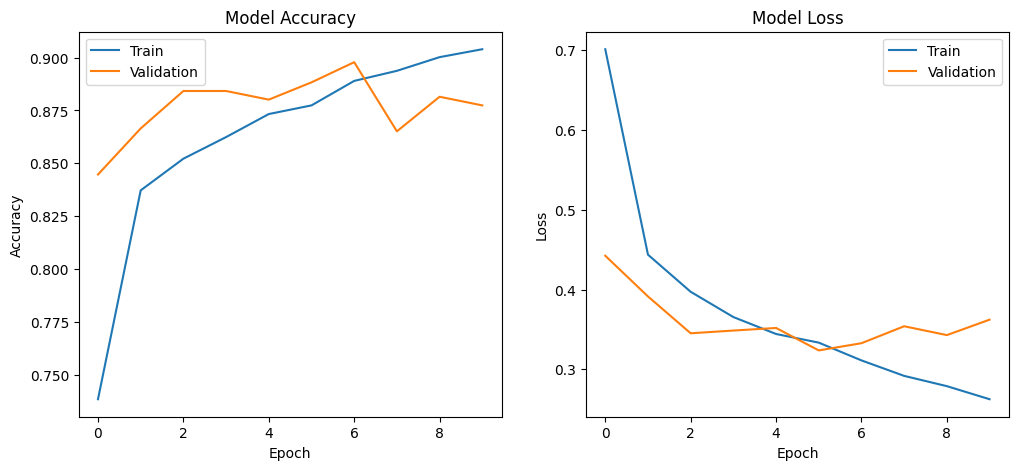

Model Saved Successfully


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os # Import os module

print("TensorFlow Version:", tf.__version__)

# =====================================================
# LOAD DATASET
# =====================================================

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

# Correct data_dir to point to the actual flower photos directory inside the extracted content
# The get_file function extracts the tgz into a directory named 'flower_photos' inside data_dir.
# So, the actual dataset is in data_dir/flower_photos.
# Let's verify the structure. Often the tarball itself contains a top-level folder.
# The typical structure after untarring is: ~/.keras/datasets/flower_photos/daisy, ~/.keras/datasets/flower_photos/dandelion, etc.
# If `data_dir` points to `~/.keras/datasets/flower_photos`, then `image_dataset_from_directory` should work directly.
# The error `Found 3670 files belonging to 1 classes.` and `Classes: ['flower_photos']` suggests that
# `image_dataset_from_directory` is seeing the `flower_photos` directory itself as a class.
# This indicates the actual classes (daisy, dandelion, etc.) are one level deeper.
# So, the path passed to `image_dataset_from_directory` should be `os.path.join(data_dir, 'flower_photos')`.

# Assuming `get_file` extracts to `data_dir` and the content of the tarball is a `flower_photos` directory containing class subdirectories
# We need to ensure `image_dataset_from_directory` points to the directory containing the class folders.
# Given the original output `Dataset Location: /root/.keras/datasets/flower_photos` and the error of 1 class,
# it implies the class subdirectories are likely within an *additional* `flower_photos` directory.
base_data_dir = data_dir
data_dir = os.path.join(data_dir, 'flower_photos')

print("Dataset Location:", data_dir)

# =====================================================
# DATASET PARAMETERS
# =====================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

# =====================================================
# OPTIMIZE DATASET
# =====================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# =====================================================
# DISPLAY SAMPLE IMAGES
# =====================================================

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# =====================================================
# DATA AUGMENTATION
# =====================================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

# =====================================================
# BUILD MOBILENETV2 MODEL
# =====================================================

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

# =====================================================
# COMPILE MODEL
# =====================================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =====================================================
# TRAIN MODEL
# =====================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# =====================================================
# EVALUATE MODEL
# =====================================================

loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

# =====================================================
# PLOT ACCURACY & LOSS
# =====================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

# =====================================================
# SAVE MODEL
# =====================================================

model.save("flower_classifier.h5")

print("Model Saved Successfully")

# =====================================================
# PREDICT NEW IMAGE
# =====================================================

# img_path = "test_flower.jpg" # This file does not exist

# img = tf.keras.utils.load_img(
#     img_path,
#     target_size=(224,224)
# )

# img_array = tf.keras.utils.img_to_array(img)
# img_array = tf.expand_dims(img_array, 0)

# predictions = model.predict(img_array)

# score = tf.nn.softmax(predictions[0])

# print(
#     "Predicted Class:",
#     class_names[np.argmax(score)]
# )

# print(
#     "Confidence:",
#     round(100*np.max(score),2),
#     "%"
# )